In [1]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fred = Fred(api_key='46d43a34faeef2972ba5eb31cf644454')

# Test pull -- US unemployment rate
unemployment = fred.get_series('UNRATE')
print(unemployment.tail(10))

2025-06-01    4.1
2025-07-01    4.3
2025-08-01    4.3
2025-09-01    4.4
2025-10-01    NaN
2025-11-01    4.5
2025-12-01    4.4
2026-01-01    4.3
2026-02-01    4.4
2026-03-01    4.3
dtype: float64


In [2]:
import sqlite3

# Pull all the indicators we need from FRED
indicators = {
    'UNRATE':   'unemployment_rate',
    'T10Y2Y':   'yield_curve',        # 10yr minus 2yr treasury spread
    'INDPRO':   'industrial_production',
    'CPIAUCSL': 'cpi_inflation',
    'FEDFUNDS': 'fed_funds_rate',
    'USREC':    'recession'           # NBER recession indicator (1=recession, 0=not)
}

# Download each series from FRED
data = {}
for code, name in indicators.items():
    data[name] = fred.get_series(code, observation_start='1960-01-01')
    print(f"Downloaded {name}: {len(data[name])} observations")

print("\nAll series downloaded successfully")

Downloaded unemployment_rate: 795 observations
Downloaded yield_curve: 13024 observations
Downloaded industrial_production: 795 observations
Downloaded cpi_inflation: 795 observations
Downloaded fed_funds_rate: 796 observations
Downloaded recession: 796 observations

All series downloaded successfully


In [3]:
# Combine all series into one dataframe
df = pd.DataFrame(data)

# The yield curve is daily data, resample to monthly to match others
df['yield_curve'] = df['yield_curve'].resample('MS').mean()

# Forward fill any missing values (common in macro data)
df = df.ffill()

# Drop rows where we don't have recession data
df = df.dropna(subset=['recession'])

# Check what we have
print(df.shape)
print(df.head())
print(f"\nRecession months: {int(df['recession'].sum())}")
print(f"Non-recession months: {int((df['recession'] == 0).sum())}")

(13392, 6)
            unemployment_rate  yield_curve  industrial_production  \
1960-01-01                5.2          NaN                24.2078   
1960-02-01                4.8          NaN                23.9924   
1960-03-01                5.4          NaN                23.7770   
1960-04-01                5.2          NaN                23.5885   
1960-05-01                5.1          NaN                23.5616   

            cpi_inflation  fed_funds_rate  recession  
1960-01-01          29.37            3.99        0.0  
1960-02-01          29.41            3.97        0.0  
1960-03-01          29.41            3.84        0.0  
1960-04-01          29.54            3.92        0.0  
1960-05-01          29.57            3.85        1.0  

Recession months: 1314
Non-recession months: 12078


In [ ]:
query = """
    SELECT 
        "index",
        unemployment_rate,
        yield_curve,
        industrial_production,
        recession
    FROM macro_indicators
    WHERE recession = 1
    LIMIT 10
"""

recession_sample = pd.read_sql_query(query, conn)
print("Sample recession months from SQL query:")
print(recession_sample)

Sample recession months from SQL query:
                 index  unemployment_rate yield_curve  industrial_production  \
0  1960-05-01 00:00:00                5.1        None                23.5616   
1  1960-06-01 00:00:00                5.4        None                23.2654   
2  1960-07-01 00:00:00                5.5        None                23.1846   
3  1960-08-01 00:00:00                5.6        None                23.1577   
4  1960-09-01 00:00:00                5.5        None                22.9153   
5  1960-10-01 00:00:00                6.1        None                22.8884   
6  1960-11-01 00:00:00                6.1        None                22.5653   
7  1960-12-01 00:00:00                6.6        None                22.1344   
8  1961-01-01 00:00:00                6.6        None                22.1613   
9  1961-02-01 00:00:00                6.9        None                22.1344   

   recession  
0        1.0  
1        1.0  
2        1.0  
3        1.0  
4   

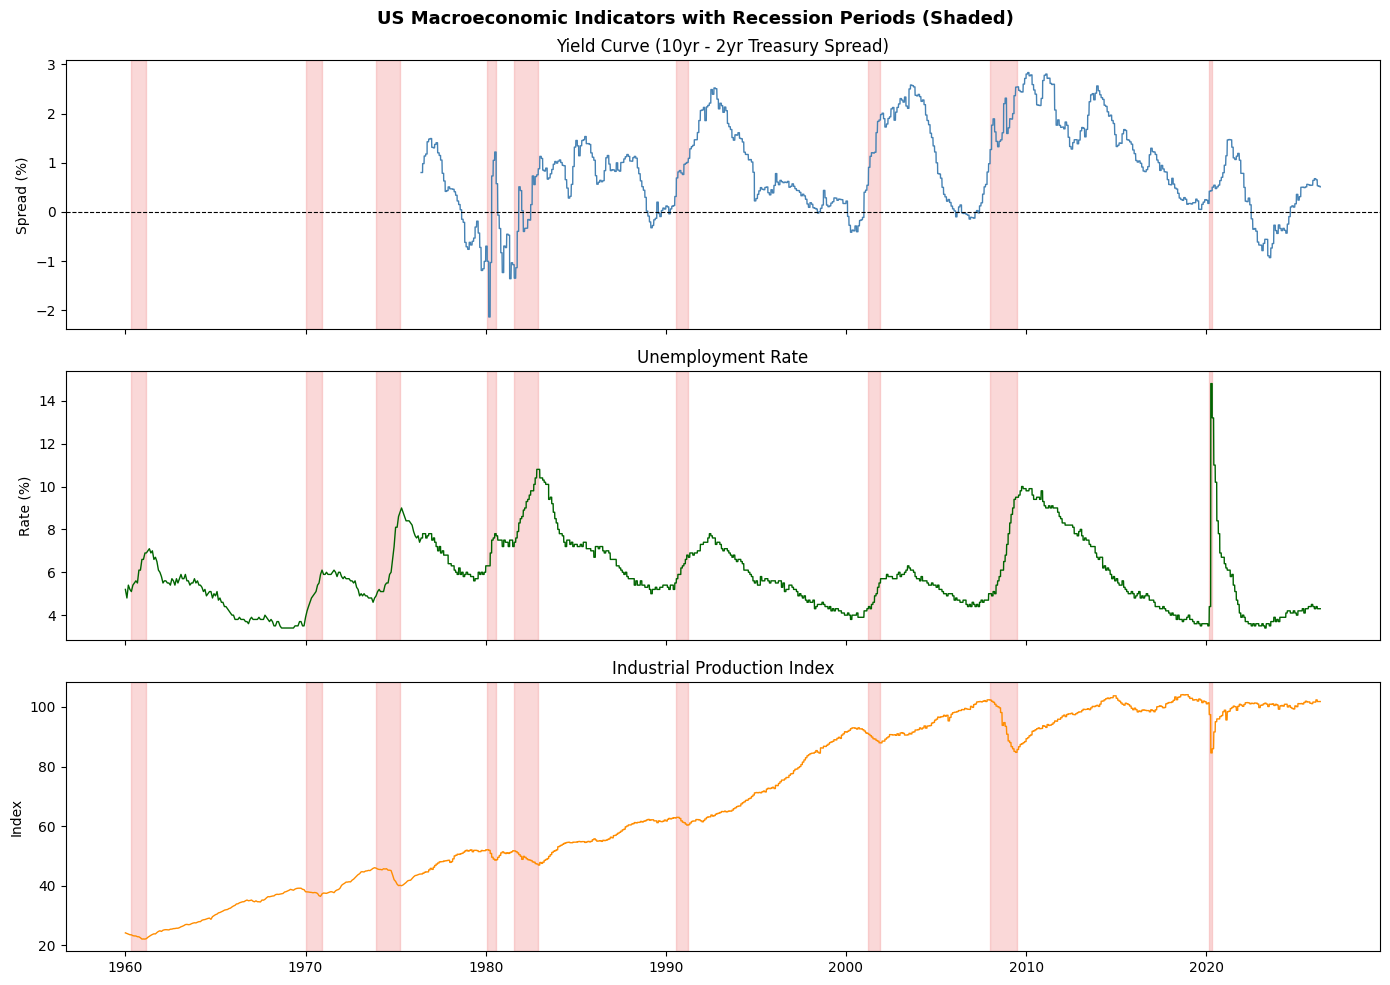

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Get recession periods for shading
recession_periods = []
in_recession = False
start = None

for date, val in df['recession'].items():
    if val == 1 and not in_recession:
        start = date
        in_recession = True
    elif val == 0 and in_recession:
        recession_periods.append((start, date))
        in_recession = False

def shade_recessions(ax):
    for start, end in recession_periods:
        ax.axvspan(start, end, color='lightcoral', alpha=0.3)

# Plot 1: Yield curve
axes[0].plot(df.index, df['yield_curve'], color='steelblue', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
shade_recessions(axes[0])
axes[0].set_ylabel('Spread (%)')
axes[0].set_title('Yield Curve (10yr - 2yr Treasury Spread)')

# Plot 2: Unemployment
axes[1].plot(df.index, df['unemployment_rate'], color='darkgreen', linewidth=1)
shade_recessions(axes[1])
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Unemployment Rate')

# Plot 3: Industrial Production
axes[2].plot(df.index, df['industrial_production'], color='darkorange', linewidth=1)
shade_recessions(axes[2])
axes[2].set_ylabel('Index')
axes[2].set_title('Industrial Production Index')

plt.suptitle('US Macroeconomic Indicators with Recession Periods (Shaded)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('indicators_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Create lagged variables -- we want to predict recession 6 months ahead
# This is what makes it a real forecasting model, not just a fit
df['yield_curve_lag6']        = df['yield_curve'].shift(6)
df['unemployment_lag6']       = df['unemployment_rate'].shift(6)
df['industrial_prod_lag6']    = df['industrial_production'].pct_change(6)
df['fed_funds_lag6']          = df['fed_funds_rate'].shift(6)

# Drop nulls created by lagging
df_model = df.dropna()

# Features and target
features = ['yield_curve_lag6', 'unemployment_lag6', 
            'industrial_prod_lag6', 'fed_funds_lag6']
X = df_model[features]
y = df_model['recession']

# Split into training (pre-2010) and test (2010 onwards)
# This is walk-forward validation -- realistic for macro forecasting
train = df_model.index < '2010-01-01'
X_train, X_test = X[train], X[~train]
y_train, y_test = y[train], y[~train]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC Score: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test_scaled)))

AUC Score: 0.725

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      4272
         1.0       0.40      0.27      0.32        45

    accuracy                           0.99      4317
   macro avg       0.70      0.63      0.66      4317
weighted avg       0.99      0.99      0.99      4317



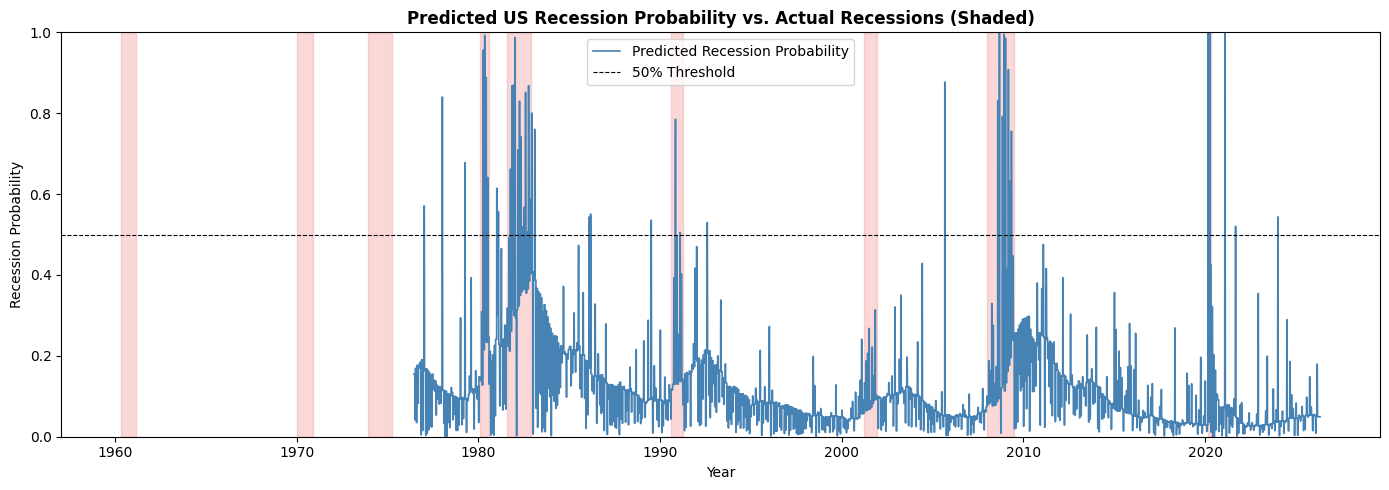

In [8]:
# Generate recession probability for the full dataset
X_all_scaled = scaler.transform(
    df_model[features]
)
df_model = df_model.copy()
df_model['recession_probability'] = model.predict_proba(X_all_scaled)[:, 1]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Shade actual recessions
for start, end in recession_periods:
    ax.axvspan(start, end, color='lightcoral', alpha=0.3, label='_nolegend_')

# Plot predicted probability
ax.plot(df_model.index, df_model['recession_probability'], 
        color='steelblue', linewidth=1.2, label='Predicted Recession Probability')

ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='50% Threshold')
ax.set_ylabel('Recession Probability')
ax.set_xlabel('Year')
ax.set_title('Predicted US Recession Probability vs. Actual Recessions (Shaded)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('recession_probability.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Save the final dataset to SQL for the record
df_model.to_sql('recession_model_output', conn, if_exists='replace', index=True)

# Confirm tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql_query(query, conn)
print("Tables in database:")
print(tables)

# Close connection
conn.close()
print("\nDatabase saved and closed successfully")

Tables in database:
                     name
0        macro_indicators
1  recession_model_output

Database saved and closed successfully
